#Naive Bayes

Naive Bayes → Supervised Learning → Classification

Naive Bayes → Supervised Learning → Regression

but naive bayes is mainly used in classification , better performance in Classification , but it can work in both regression and classification

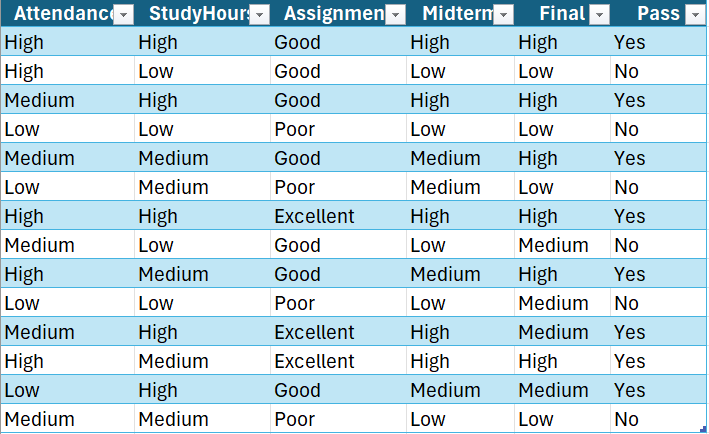

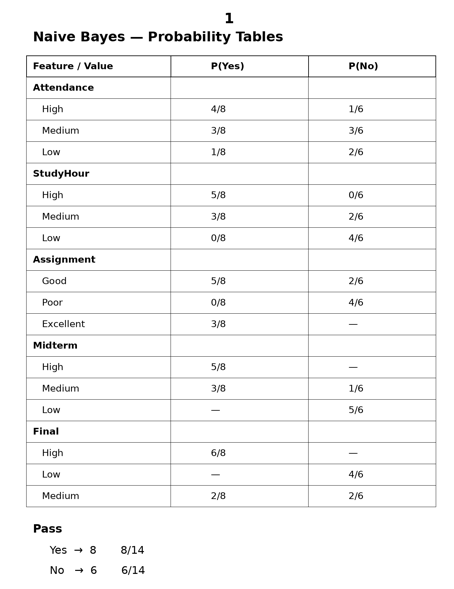

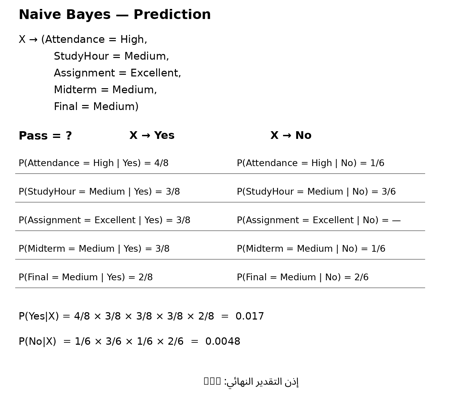

1. Naive bayes - very fast
2. used in binary classification - multi classification
3. Catergorical data , category wasn't present in the training data the model will assign it to "Zero" so it won't be able to make any predictions


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor


from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df=pd.read_excel("/content/Grades.xlsx")

In [ ]:
df.head()

,Attendance,StudyHours,Assignment,Midterm,Final,Pass
0,High,High,Good,High,High,1
1,High,Low,Good,Low,Low,0
2,Medium,High,Good,High,High,1
3,Low,Low,Poor,Low,Low,0
4,Medium,Medium,Good,Medium,High,1


In [ ]:

X = df.drop('Pass', axis=1)
y = df['Pass']

In [ ]:
# Encode X
encoder_X = OrdinalEncoder()

X = pd.DataFrame(
    encoder_X.fit_transform(X),
    columns=X.columns
)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:")
display(X_train.head())

print("X_test:")
display(X_test.head())

print("y_train:")
display(y_train.head())

print("y_test:")
display(y_test.head())

X_train:


,Attendance,StudyHours,Assignment,Midterm,Final
12,1.0,0.0,1.0,2.0,2.0
5,1.0,2.0,2.0,2.0,1.0
8,0.0,2.0,1.0,2.0,0.0
2,2.0,0.0,1.0,0.0,0.0
1,0.0,1.0,1.0,1.0,1.0


X_test:


,Attendance,StudyHours,Assignment,Midterm,Final
9,1.0,1.0,2.0,1.0,2.0
11,0.0,2.0,0.0,0.0,0.0
0,0.0,0.0,1.0,0.0,0.0


y_train:


,Pass
12,1
5,0
8,1
2,1
1,0


y_test:


,Pass
9,0
11,1
0,1


In [ ]:
model = CategoricalNB()
model.fit(X_train, y_train)

CategoricalNB()

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
print("Training Accuracy:",
      accuracy_score(y_train, y_train_pred))

print("Testing Accuracy:",
      accuracy_score(y_test, y_test_pred))



Training Accuracy: 1.0
Testing Accuracy: 1.0


Test the model with new student

In [ ]:
new_student = pd.DataFrame({
    "Attendance": ["High"],
    "StudyHours": ["High"],
    "Assignment": ["Excellent"],
    "Midterm": ["Low"],
    "Final": ["Low"]
})


new_student_encoded = encoder_X.transform(new_student)

# Predict using the trained model
prediction = model.predict(new_student_encoded)

print(prediction)

[0]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


#We have 3 Types of Naive Bayes



1. Gaussian Naive Bayes

       when we have in the data continous values
       (Age, Salary, Height, Temperature)

       from sklearn.naive_bayes import GaussianNB
       model = GaussianNB()
       model.fit(X_train, y_train)

2. Multinomail NAive Bayes

       Counts|Freq (1,2,3,4)

       from sklearn.naive_bayes import MultinomialNB
       model = MultinomialNB()
       model.fit(X_train, y_train)

3. Bernoulli Naive Bayes

       (binary Data)
       from sklearn.naive_bayes import BernoulliNB
       model = BernoulliNB()
       model.fit(X_train, y_train)